In [1]:
%load_ext autoreload
%autoreload 2
from helpers import *
from SINDyModel import *

In [2]:
# make a specific Lotka-Volterra right-hand side function
lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)

In [3]:
# evaluate how models perform with different time steps

t_span = (0, 30)
x0 = (10, 5)

threshold = 0.05
noise_level = 0.01 # set a fixed noise level for all tests

# dts = np.linspace(0.01, 1, 10)
dts = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]

t_evals = []
x_trains = []
models = []
x_preds = []
for dt in tqdm(dts):
    # generate evaluation time points
    t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
    t_evals.append(t_eval)

    # generate training data
    x_train = generate_training_data(lotka_volterra_rhs, x0, t_eval)
    x_trains.append(x_train)
    
    # generate noisy data
    x_train_noisy = add_noise_to_data(x_train, noise_level)
    # generate the derivative of the noisy data
    x_dot_approx = dxdt(x_train_noisy, t_eval, kind="finite_difference", k=1)
    
    # create and fit a SINDy model
    model = SINDyModel(n_state_vars=2, threshold=threshold, poly_order=5)
    model.fit(x_train_noisy, x_dot_approx)
    models.append(model)
    
    x_pred = generate_model_prediction(model, x0, t_eval)
    x_preds.append(x_pred)

    # print the model if it failed to generate a prediction
    if x_pred is None:
        print(f"failed to generate model prediction for model trained with dt={dt}")


# print the models
for i in range(len(dts)):
    print(f"dt: {dts[i]}")
    models[i].print()
    print()

 43%|████▎     | 3/7 [00:04<00:05,  1.47s/it]c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\SINDyModel.py:9: RuntimeWarning: overflow encountered in power
  return lambda x: np.prod(np.power(x, power_tuple), axis=1)
c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\SINDyModel.py:145: RuntimeWarning: invalid value encountered in matmul
  x_dot = Theta @ self.Xi
c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  solver._y, solver.t = integrator.run(
 57%|█████▋    | 4/7 [00:10<00:10,  3.42s/it]

failed to generate model prediction for model trained with dt=0.1


100%|██████████| 7/7 [00:19<00:00,  2.75s/it]

failed to generate model prediction for model trained with dt=1
dt: 0.01
x0' = + 0.99805 x0 + -0.10008 x0 x1 
x1' = + 0.74996 x0 x1 + -1.49914 x1 

dt: 0.02
x0' = + 0.99530 x0 + -0.09981 x0 x1 
x1' = + 0.74837 x0 x1 + -1.49617 x1 

dt: 0.05
x0' = + 0.98546 x0 + -0.09907 x0 x1 
x1' = + 0.74147 x0 x1 + -1.47970 x1 

dt: 0.1
x0' = + 0.95689 x0 + -0.09685 x0 x1 
x1' = + -0.27536 x0 + 0.71421 x0 x1 + 0.06479 x0^2 + -1.43583 x1 

dt: 0.2
x0' = + 0.84633 x0 + -0.08804 x0 x1 
x1' = + -3.35492 1 + 6.97213 x0 + 0.62572 x0 x1 + -2.12891 x0^2 + 0.16386 x0^3 + -1.26192 x1 

dt: 0.5
x0' = + -0.17633 1 + -0.16061 x0 + -0.05532 x0 x1 + 0.58004 x0^2 + -0.05924 x0^3 
x1' = + -1.28305 1 + 1.93522 x0 + 2.88863 x0 x1 + -0.68521 x0^2 + -0.83300 x0^2 x1 + 0.07274 x0^3 + 0.06962 x0^3 x1 + -1.61225 x1 

dt: 1
x0' = + 0.75228 x0 + -0.27994 x0 x1 
x1' = + 2.02573 1 + -6.97786 x0 + 8.83343 x0 x1 + -0.31247 x0 x1^2 + 5.59781 x0^2 + -5.56692 x0^2 x1 + 0.24879 x0^2 x1^2 + -1.43411 x0^3 + 1.22922 x0^3 x1 + 0.11544 x0

In [4]:
for i in range(len(dts)):
    if x_preds[i] is None:
        print(f"dt: {dts[i]:.6f}, failed to generate model prediction")
        continue
    rte = relative_trajectory_error(x_trains[i], x_preds[i])
    print(f"dt: {dts[i]:.6f}, relative trajectory error: {rte:.6f}")

dt: 0.010000, relative trajectory error: 0.002031
dt: 0.020000, relative trajectory error: 0.012300
dt: 0.050000, relative trajectory error: 0.149021
dt: 0.100000, failed to generate model prediction
dt: 0.200000, relative trajectory error: 0.502861
dt: 0.500000, relative trajectory error: 0.931509
dt: 1.000000, failed to generate model prediction


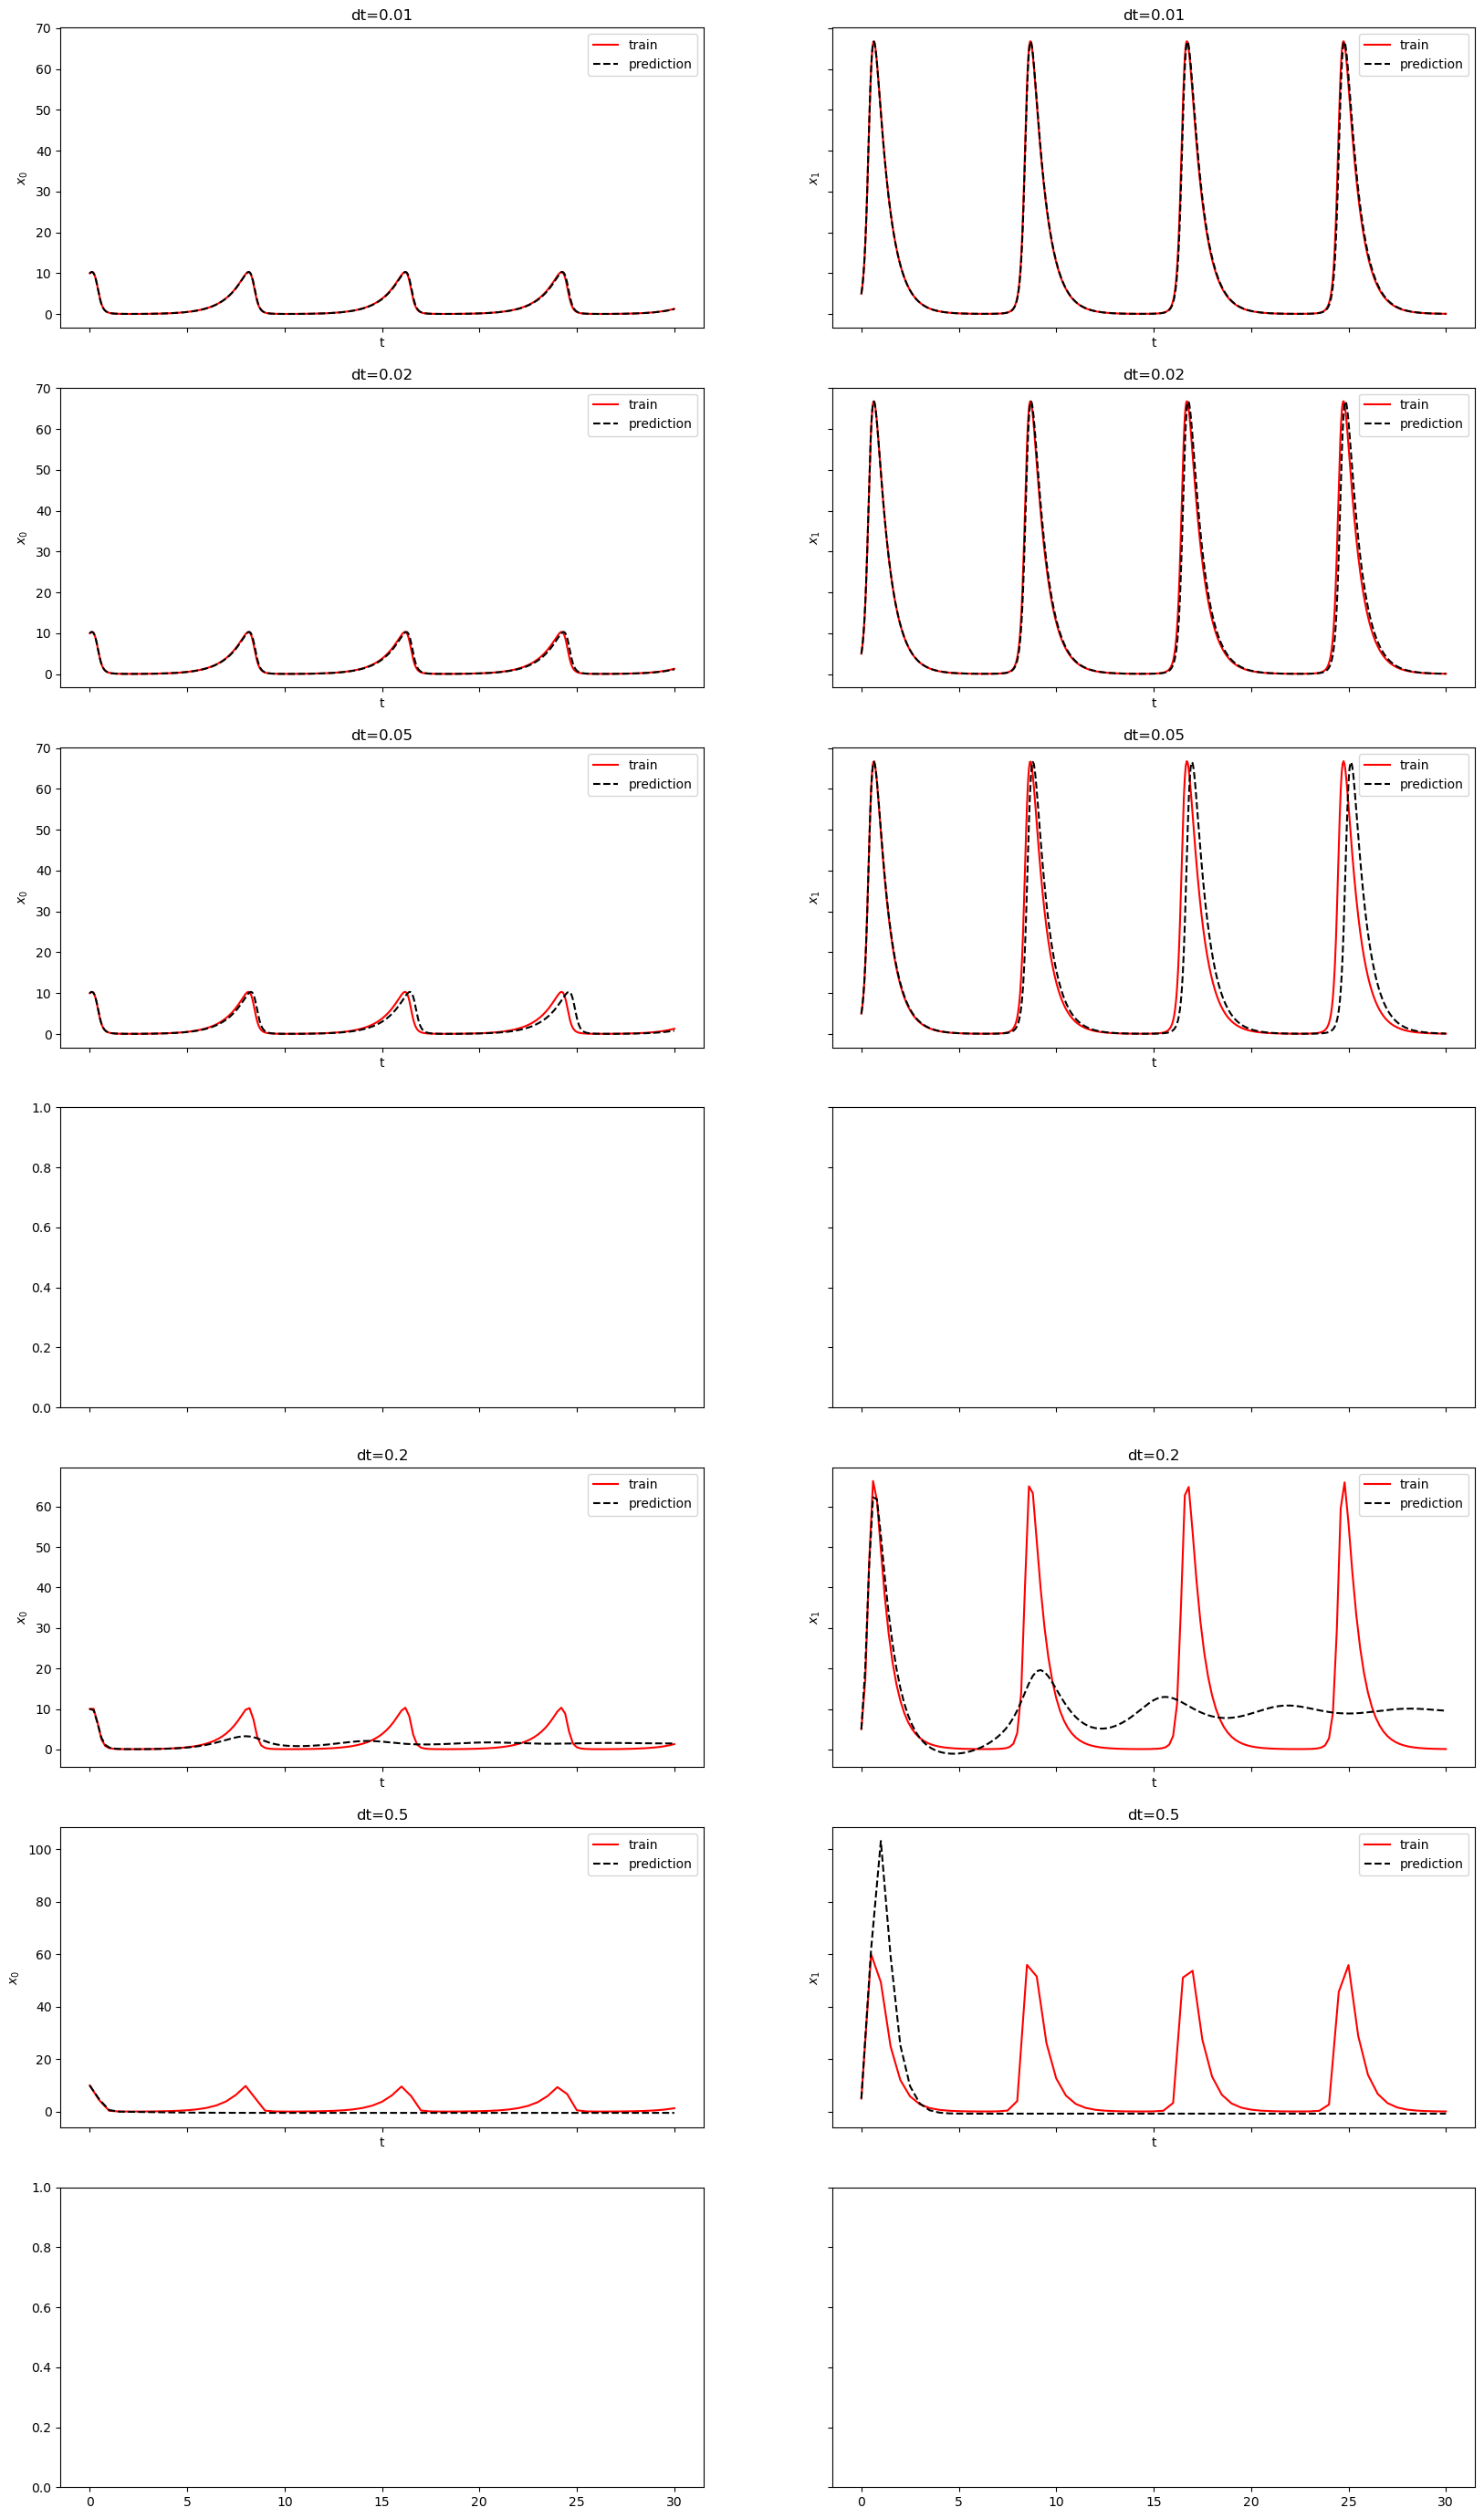

In [9]:
# plot the results

n_dts = len(dts)
n_svs = len(x0)

fig, axs = plt.subplots(n_dts, n_svs, figsize=(10*n_svs, 5*n_dts), sharex='col', sharey='row')

for dt_idx in range(n_dts):
    # skip if the model prediction failed
    if x_preds[dt_idx] is None:
        continue

    for sv_idx in range(n_svs):
        # plot the sv_idx'th training state variable
        axs[dt_idx, sv_idx].plot(t_evals[dt_idx], x_trains[dt_idx][sv_idx], "r", label="train")
        
        # plot the sv_idx'th state variable model prediction
        axs[dt_idx, sv_idx].plot(t_evals[dt_idx], x_preds[dt_idx][sv_idx], "k--", label="prediction")

        # set the title and labels
        axs[dt_idx, sv_idx].set_title(f"dt={dts[dt_idx]}")
        axs[dt_idx, sv_idx].set_xlabel("t")
        axs[dt_idx, sv_idx].set_ylabel(f"$x_{sv_idx}$")
        axs[dt_idx, sv_idx].legend()